# Importar libs

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

warnings.filterwarnings('ignore')

# Carregar dados

In [2]:
gdf_queimadas = gpd.read_file('https://raw.githubusercontent.com/henrqueDev/BDQueimadas-JSON/master/bdqueimadas_2017_2025.geojson')

gdf_queimadas.dropna(inplace=True)
gdf_queimadas.set_index('DataHora', inplace=True)

gdf_queimadas = gdf_queimadas.query('Bioma == "Caatinga"')

gdf_queimadas.info()
gdf_queimadas.crs
# gdf_queimadas.explore()

<class 'geopandas.geodataframe.GeoDataFrame'>
DatetimeIndex: 7167 entries, 2025-01-01 16:52:00 to 2017-12-31 15:33:00
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Satelite      7167 non-null   object  
 1   Pais          7167 non-null   object  
 2   Estado        7167 non-null   object  
 3   Municipio     7167 non-null   object  
 4   Bioma         7167 non-null   object  
 5   DiaSemChuva   7167 non-null   float64 
 6   Precipitacao  7167 non-null   float64 
 7   RiscoFogo     7167 non-null   float64 
 8   FRP           7167 non-null   float64 
 9   geometry      7167 non-null   geometry
dtypes: float64(4), geometry(1), object(5)
memory usage: 615.9+ KB


<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Carregar GeoJSON das cidades da PB

In [3]:
gdf_pb_cidades = gpd.read_file('GEOJSON:https://raw.githubusercontent.com/henrqueDev/BDQueimadas-JSON/master/pb_cidades.geojson')
gdf_pb_cidades['CD_MUN'] = gdf_pb_cidades['CD_MUN'].astype('int64')
gdf_pb_cidades.info()

gdf_pb_cidades.crs

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   NM_MUN      223 non-null    object  
 1   CD_SETOR    223 non-null    object  
 2   SITUACAO    223 non-null    object  
 3   CD_SIT      223 non-null    object  
 4   CD_TIPO     223 non-null    object  
 5   AREA_KM2    223 non-null    float64 
 6   CD_REGIAO   223 non-null    object  
 7   NM_REGIAO   223 non-null    object  
 8   CD_UF       223 non-null    object  
 9   NM_UF       223 non-null    object  
 10  CD_MUN      223 non-null    int64   
 11  CD_DIST     223 non-null    object  
 12  NM_DIST     223 non-null    object  
 13  CD_SUBDIST  223 non-null    object  
 14  NM_SUBDIST  0 non-null      object  
 15  CD_BAIRRO   12 non-null     object  
 16  NM_BAIRRO   12 non-null     object  
 17  CD_NU       20 non-null     object  
 18  NM_NU       20 non-null     object  
 19  

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

# Converter para Sistema Geodésico Mundial

In [4]:
gdf_queimadas = gdf_queimadas.to_crs(epsg=4326)
gdf_pb_cidades = gdf_pb_cidades.to_crs(epsg=4326)

print(f'BDQueimadas CRS -> {gdf_queimadas.crs}')
print(f'Malha municípios CRS -> {gdf_pb_cidades.crs}')

BDQueimadas CRS -> EPSG:4326
Malha municípios CRS -> EPSG:4326


In [5]:
gdf_queimadas.describe()

,DiaSemChuva,Precipitacao,RiscoFogo,FRP
count,7167.000000,7167.000000,7167.000000,7167.000000
mean,26.158923,0.294475,-1.476997,49.008204
std,31.151624,1.660489,48.644080,69.896363
min,0.000000,0.000000,-999.000000,4.400000
25%,4.000000,0.000000,1.000000,16.900000
50%,11.000000,0.000000,1.000000,29.000000
75%,39.000000,0.000000,1.000000,54.750000
max,268.000000,40.900000,1.000000,1155.600000


# Mapear dias

In [7]:
import numpy as np

num_meses = 365

anos_index = gdf_queimadas.index.year
dias_index = gdf_queimadas.index.day

gdf_queimadas['day_sin'] = np.sin((2 * np.pi * dias_index) / num_meses)

gdf_queimadas['day_cos'] = np.cos((2 * np.pi * dias_index) / num_meses)
gdf_queimadas['ano'] = anos_index
gdf_queimadas

,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,FRP,geometry,day_sin,day_cos,ano
DataHora,,,,,,,,,,,,,
2025-01-01 16:52:00,AQUA_M-T,Brasil,PARAÍBA,BONITO DE SANTA FÉ,Caatinga,4.0,0.00,1.0,17.4,POINT (-38.53855 -7.25636),0.017213,0.999852,2025
2025-01-02 17:32:00,AQUA_M-T,Brasil,PARAÍBA,ITAPORANGA,Caatinga,23.0,0.00,1.0,33.3,POINT (-38.20256 -7.26206),0.034422,0.999407,2025
2025-01-03 16:34:00,AQUA_M-T,Brasil,PARAÍBA,IBIARA,Caatinga,4.0,0.57,1.0,84.4,POINT (-38.42987 -7.5416),0.051620,0.998667,2025
2025-01-03 16:34:00,AQUA_M-T,Brasil,PARAÍBA,SOLÂNEA,Caatinga,25.0,0.00,1.0,25.0,POINT (-35.71262 -6.81057),0.051620,0.998667,2025
2025-01-03 16:34:00,AQUA_M-T,Brasil,PARAÍBA,IBIARA,Caatinga,4.0,0.70,1.0,111.1,POINT (-38.43714 -7.53861),0.051620,0.998667,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-30 16:28:00,AQUA_M-T,Brasil,PARAÍBA,SOUSA,Caatinga,0.0,0.00,1.0,26.5,POINT (-38.224 -6.736),0.493776,0.869589,2017
2017-12-31 15:33:00,AQUA_M-T,Brasil,PARAÍBA,MONTEIRO,Caatinga,8.0,0.00,1.0,54.4,POINT (-37.166 -7.831),0.508671,0.860961,2017
2017-12-31 15:33:00,AQUA_M-T,Brasil,PARAÍBA,SOUSA,Caatinga,7.0,0.00,1.0,74.2,POINT (-38.143 -6.828),0.508671,0.860961,2017


# **Ignorar**

In [8]:
incendios_pb = gpd.sjoin(
    gdf_queimadas,
    gdf_pb_cidades,
    predicate="within",
    how="left"
)

fogo_por_mun = (
    incendios_pb.groupby("NM_MUN")
    .size()
    .rename("ocorrencias")
)

gdf_pb_cidades = gdf_pb_cidades.merge(
    fogo_por_mun,
    on="NM_MUN",
    how="outer"
)

incendios_pb.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
DatetimeIndex: 7167 entries, 2025-01-01 16:52:00 to 2017-12-31 15:33:00
Data columns (total 43 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Satelite      7167 non-null   object  
 1   Pais          7167 non-null   object  
 2   Estado        7167 non-null   object  
 3   Municipio     7167 non-null   object  
 4   Bioma         7167 non-null   object  
 5   DiaSemChuva   7167 non-null   float64 
 6   Precipitacao  7167 non-null   float64 
 7   RiscoFogo     7167 non-null   float64 
 8   FRP           7167 non-null   float64 
 9   geometry      7167 non-null   geometry
 10  day_sin       7167 non-null   float64 
 11  day_cos       7167 non-null   float64 
 12  ano           7167 non-null   int32   
 13  index_right   7167 non-null   int64   
 14  NM_MUN        7167 non-null   object  
 15  CD_SETOR      7167 non-null   object  
 16  SITUACAO      7167 non-null   object  
 17  CD_SIT  

# **Métodos de medidas e métricas de coordenadas e tempo**

In [ ]:
eps_spatial = 1
eps_temporal = 5940

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

def st_distance_metric_haversine(point1, point2):
  spatial_distance = haversine(point1[1], point1[0], point2[1], point2[0])

  temporal_distance = abs(point1[2] - point2[2])

  if spatial_distance <= eps_spatial and temporal_distance <= eps_temporal:
      return 0
  else:
      return np.inf

# **Spatial-Temporal Clustering (DBSCAN)**

Filtrar os registros e atribuir Unix timestamp

In [68]:
local = "Cajazeiras"

#incendios_local = incendios_pb[incendios_pb['NM_MUN'] == local]

incendios_local = incendios_pb

incendios_local_sem = incendios_local[
    (incendios_local.index > "2017/01/01 00:00:00") &
    (incendios_local.index < "2025/12/31 00:00:00")
].tz_localize('UTC')

Latitude = incendios_local_sem.geometry.y.values
Longitude = incendios_local_sem.geometry.x.values

temporal_data = (incendios_local_sem.index.astype(np.int64) / (10**6)) * (10**5)

X_coords_radianos = np.deg2rad(np.vstack([Longitude, Latitude])).T
X_coords_radianos = np.column_stack((X_coords_radianos, temporal_data))
print(X_coords_radianos[0,1])

-0.12664737371001572


Algoritmo ST-DBSCAN

In [69]:
clusterer = DBSCAN(
    min_samples=2,
    metric=st_distance_metric_haversine,
    n_jobs=8
)

clusters = clusterer.fit_predict(X_coords_radianos)

labels_dbscan = clusterer.labels_
n_clusters_dbscan = len(np.unique(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

df_processed_incendios = incendios_local_sem.copy()
df_processed_incendios['latitude_rad'] = X_coords_radianos[:, 1]
df_processed_incendios['longitude_rad'] = X_coords_radianos[:, 0]
df_processed_incendios['unix_time'] = X_coords_radianos[:, 2]
df_processed_incendios['cluster_label'] = clusters

print(f"ST-DBSCAN encontrou {n_clusters_dbscan} clusters.")
display(df_processed_incendios[['FRP', 'RiscoFogo', 'DiaSemChuva', 'latitude_rad', 'longitude_rad', 'cluster_label', 'unix_time']])

coords = df_processed_incendios[['FRP','DiaSemChuva','RiscoFogo', 'latitude_rad', 'longitude_rad','unix_time', 'cluster_label']]

ST-DBSCAN encontrou 1106 clusters.


,FRP,RiscoFogo,DiaSemChuva,latitude_rad,longitude_rad,cluster_label,unix_time
DataHora,,,,,,,
2025-01-01 16:52:00+00:00,17.4,1.0,4.0,-0.126647,-0.672625,-1,1.735750e+11
2025-01-02 17:32:00+00:00,33.3,1.0,23.0,-0.126747,-0.666760,-1,1.735839e+11
2025-01-03 16:34:00+00:00,84.4,1.0,4.0,-0.131626,-0.670728,0,1.735922e+11
2025-01-03 16:34:00+00:00,25.0,1.0,25.0,-0.118867,-0.623303,-1,1.735922e+11
2025-01-03 16:34:00+00:00,111.1,1.0,4.0,-0.131574,-0.670855,0,1.735922e+11
...,...,...,...,...,...,...,...
2017-12-30 16:28:00+00:00,26.5,1.0,0.0,-0.117565,-0.667135,1104,1.514651e+11
2017-12-31 15:33:00+00:00,54.4,1.0,8.0,-0.136677,-0.648669,-1,1.514734e+11
2017-12-31 15:33:00+00:00,74.2,1.0,7.0,-0.119171,-0.665721,1105,1.514734e+11


# **Métricas de avaliação da clsuterização**

In [ ]:
clusters_labeled = labels_dbscan != -1
ruido = labels_dbscan == -1

if n_clusters_dbscan > 1:

    score_calinski_dbscan = calinski_harabasz_score(
        X_coords_radianos[clusters_labeled],    # Tá com problemas (escala do tempo muito mais pesada que a espacial)
        labels_dbscan[clusters_labeled]
    )

    score_silhouette_dbscan = silhouette_score(
        X_coords_radianos[clusters_labeled],
        labels_dbscan[clusters_labeled],    # Problema com a métrica: valores possíveis binários
        metric=st_distance_metric_haversine
    )

    score_davies_dbscan = davies_bouldin_score(
      X_coords_radianos[clusters_labeled],  # Esse está ok
      labels_dbscan[clusters_labeled]
    )

    print("Métricas ST-DBSCAN")
    print(f'Calinski–Harabasz : {score_calinski_dbscan}')
    print(f"Silhouette Score (Excluindo Ruído): {score_silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Score (Excluindo Ruído): {score_davies_dbscan:.4f}")
else:
    print("\nDBSCAN não encontrou clusters válidos (ou apenas 1)")

Métricas ST-DBSCAN
Calinski–Harabasz : 8.256234822195885e+24
Silhouette Score (Excluindo Ruído): 0.0000
Davies-Bouldin Score (Excluindo Ruído): 0.0000


# **Plot 2D**

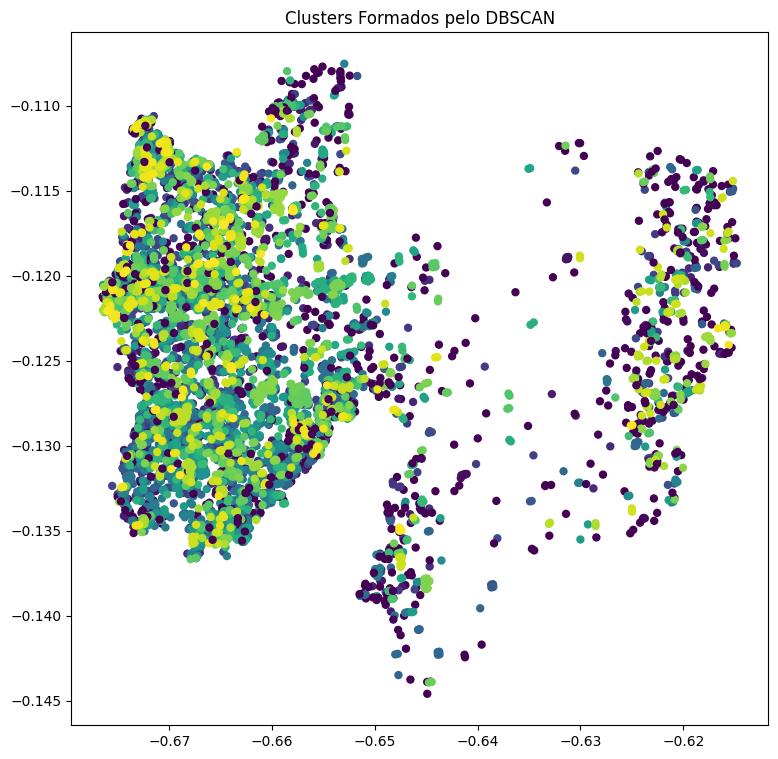

In [ ]:
import matplotlib.pyplot as plt

coords['fire'] = 1
labels = clusterer.labels_

plt.figure(figsize=(9,9))
plt.scatter(coords.longitude_rad, coords.latitude_rad, c=labels, s=25, cmap='viridis')
plt.title("Clusters Formados pelo DBSCAN")

plt.show()

# **Plot 3D**

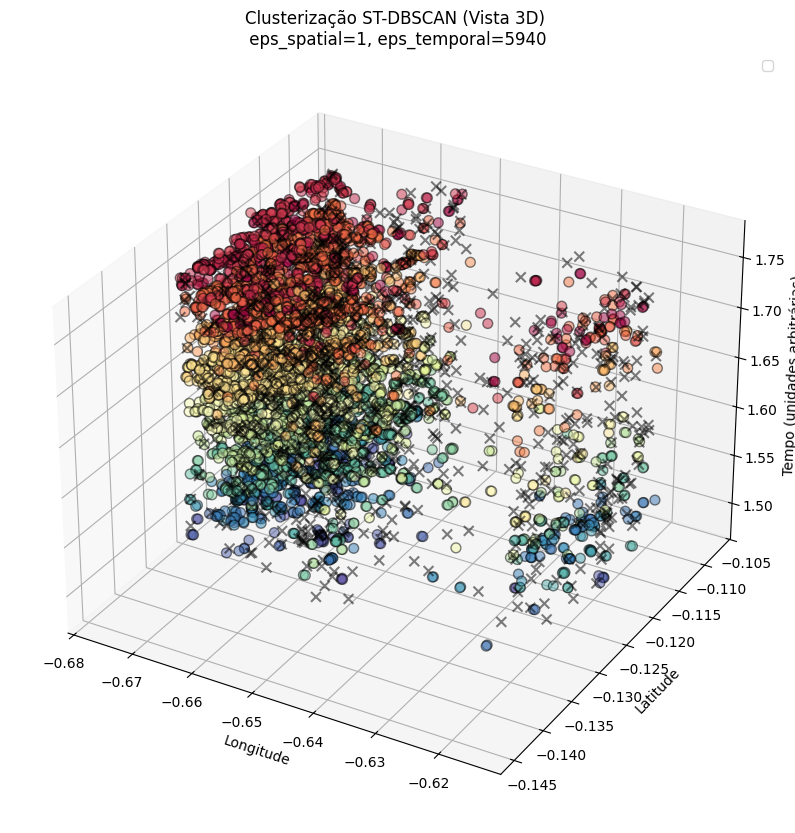

In [80]:
colors = plt.cm.Spectral(np.linspace(0, 1, len(labels)))

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
labels = set(clusterer.labels_)

for k, col in zip(labels, colors):
    if k == -1:
        col = 'k'
        marker = 'x'
        edge_color = None
    else:
        marker = 'o'
        edge_color = 'k'

    class_member_mask = (clusters == k)
    xyzt = coords.query(f'cluster_label == {k}')
    ax.scatter(xyzt['longitude_rad'], xyzt['latitude_rad'], xyzt['unix_time'], c=[col], edgecolors=edge_color, s=50,
               marker=marker, alpha=0.5)

ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_zlabel('Tempo (unidades arbitrárias)')
ax.set_title(f'Clusterização ST-DBSCAN (Vista 3D)\n eps_spatial={eps_spatial}, eps_temporal={eps_temporal}')
plt.legend()
plt.show()

# **Verificar ruído**

In [85]:
coords_ruido = coords.query("cluster_label == -1")
coords_ruido

,FRP,DiaSemChuva,RiscoFogo,latitude_rad,longitude_rad,unix_time,cluster_label,fire
DataHora,,,,,,,,
2025-01-01 16:52:00+00:00,17.4,4.0,1.0,-0.126647,-0.672625,1.735750e+11,-1,1
2025-01-02 17:32:00+00:00,33.3,23.0,1.0,-0.126747,-0.666760,1.735839e+11,-1,1
2025-01-03 16:34:00+00:00,25.0,25.0,1.0,-0.118867,-0.623303,1.735922e+11,-1,1
2025-01-03 16:34:00+00:00,23.3,32.0,1.0,-0.128191,-0.624142,1.735922e+11,-1,1
2025-01-04 17:11:00+00:00,40.2,19.0,1.0,-0.132121,-0.658141,1.736011e+11,-1,1
...,...,...,...,...,...,...,...,...
2017-12-27 15:57:00+00:00,40.4,0.0,0.9,-0.135542,-0.665791,1.514390e+11,-1,1
2017-12-27 15:57:00+00:00,16.2,0.0,1.0,-0.129730,-0.658443,1.514390e+11,-1,1
2017-12-27 15:57:00+00:00,22.6,0.0,1.0,-0.122487,-0.674378,1.514390e+11,-1,1


# **Converter novamente para GeoDataFrame**

In [81]:
from shapely.geometry import Point

rad_in_degrees = np.rad2deg(np.vstack([coords.latitude_rad, coords.longitude_rad])).T
coords_real = [Point(xy) for xy in zip(rad_in_degrees[:, 1], rad_in_degrees[:, 0])]
gdf_coords_all = gpd.GeoDataFrame(coords, geometry=coords_real, crs='EPSG:4326')

gdf_coords_all

,FRP,DiaSemChuva,RiscoFogo,latitude_rad,longitude_rad,unix_time,cluster_label,fire,geometry
DataHora,,,,,,,,,
2025-01-01 16:52:00+00:00,17.4,4.0,1.0,-0.126647,-0.672625,1.735750e+11,-1,1,POINT (-38.53855 -7.25636)
2025-01-02 17:32:00+00:00,33.3,23.0,1.0,-0.126747,-0.666760,1.735839e+11,-1,1,POINT (-38.20256 -7.26206)
2025-01-03 16:34:00+00:00,84.4,4.0,1.0,-0.131626,-0.670728,1.735922e+11,0,1,POINT (-38.42987 -7.5416)
2025-01-03 16:34:00+00:00,25.0,25.0,1.0,-0.118867,-0.623303,1.735922e+11,-1,1,POINT (-35.71262 -6.81057)
2025-01-03 16:34:00+00:00,111.1,4.0,1.0,-0.131574,-0.670855,1.735922e+11,0,1,POINT (-38.43714 -7.53861)
...,...,...,...,...,...,...,...,...,...
2017-12-30 16:28:00+00:00,26.5,0.0,1.0,-0.117565,-0.667135,1.514651e+11,1104,1,POINT (-38.224 -6.736)
2017-12-31 15:33:00+00:00,54.4,8.0,1.0,-0.136677,-0.648669,1.514734e+11,-1,1,POINT (-37.166 -7.831)
2017-12-31 15:33:00+00:00,74.2,7.0,1.0,-0.119171,-0.665721,1.514734e+11,1105,1,POINT (-38.143 -6.828)


In [17]:
gdf_cities_map = gdf_pb_cidades.explore(
    color='blue',
    tiles="cartodbdarkmatter"
)

gdf_map = gdf_coords_all.explore(m=gdf_cities_map,column='cluster_label', cmap='gist_rainbow')

#gdf_map

ImportError: The 'folium>=0.12', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge "folium>=0.12" matplotlib mapclassify' or 'pip install "folium>=0.12" matplotlib mapclassify'.

# Agrupar Centroides + Manipular Matrizes

In [82]:
def centroid(gdf: gpd.GeoDataFrame):
  centroids_class = []
  for cluster, points in gdf.groupby('cluster_label'):
    points_size = len(points)

    if points_size == 0:
        continue
    elif cluster == -1:
        centroids_class.append(
          gpd.GeoDataFrame(points,
          geometry=[point.geometry for point in points.itertuples()],
          columns=['FRP',	'DiaSemChuva', 'latitude_rad',
                   'longitude_rad', 'RiscoFogo',	'unix_time',	'cluster_label',	'fire'],
          crs='EPSG:4326',
          index=points.index)
        )

        continue

    centroid_y = np.sum(np.radians(points.geometry.y)) / points_size
    centroid_x = np.sum(np.radians(points.geometry.x)) / points_size

    frp_total = np.sum(points.FRP)
    dry_days_mean = np.mean(points.DiaSemChuva)
    fire_risk = np.mean(points.RiscoFogo)
    fire = 1

    centroid_data = [frp_total, dry_days_mean, centroid_y, centroid_x, fire_risk, (points.index.astype(np.int64)[0] / 10**6)*(10**5), cluster, fire]
    centroids_class.append(
      gpd.GeoDataFrame([centroid_data],
      geometry=[Point(np.rad2deg(centroid_x), np.rad2deg(centroid_y))],
      columns=['FRP',	'DiaSemChuva',	'latitude_rad',	'longitude_rad', 'RiscoFogo',
               'unix_time',	'cluster_label',	'fire'],
      crs='EPSG:4326',
      index=[points.index[0]]))

  if centroids_class:
      return pd.concat(centroids_class)
  else:
      return gpd.GeoDataFrame(columns=['FRP', 'RiscoFogo','DiaSemChuva', 'cluster_label'], geometry=[], crs='EPSG:4326', index=pd.DatetimeIndex([]))

gdf_clustered = centroid(gdf_coords_all)
gdf_clustered.info()
print(f"CRS = {gdf_clustered.crs}")

<class 'geopandas.geodataframe.GeoDataFrame'>
DatetimeIndex: 2050 entries, 2025-01-01 16:52:00+00:00 to 2017-12-31 15:33:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   FRP            2050 non-null   float64 
 1   DiaSemChuva    2050 non-null   float64 
 2   latitude_rad   2050 non-null   float64 
 3   longitude_rad  2050 non-null   float64 
 4   RiscoFogo      2050 non-null   float64 
 5   unix_time      2050 non-null   float64 
 6   cluster_label  2050 non-null   int64   
 7   fire           2050 non-null   int64   
 8   geometry       2050 non-null   geometry
dtypes: float64(6), geometry(1), int64(2)
memory usage: 160.2 KB
CRS = EPSG:4326


In [ ]:
gdf_cities_map = gdf_pb_cidades.explore(
    color='blue',
    tiles="cartodbdarkmatter"
)

gdf_map_clustered = gdf_clustered.query('cluster_label != -1').explore(m=gdf_cities_map,column='cluster_label', cmap='gist_rainbow')

gdf_map_clustered

# **Distribuição espacial dos registros**

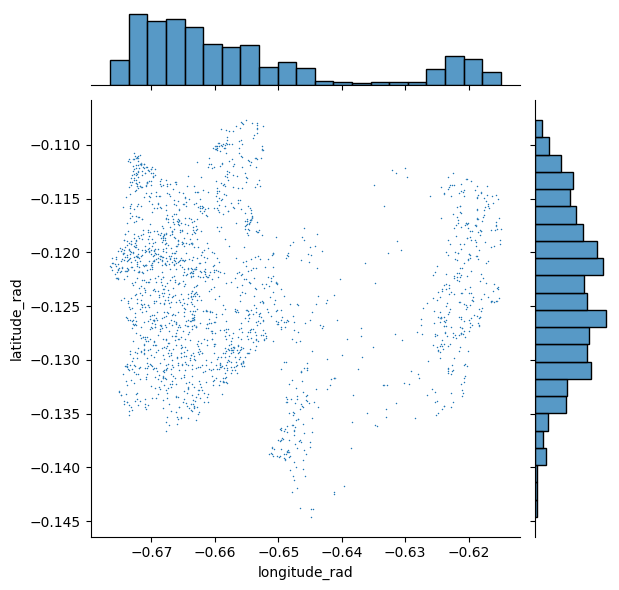

In [84]:
sns.jointplot(x="longitude_rad", y="latitude_rad", data=gdf_clustered, s=1.2)